In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

# Load cleaned data
df = pd.read_csv(r"C:\Users\Suhani\Desktop\india-health-analysis\data\cleaned\NFHS_5_cleaned.csv")

# Filter to Total rows only and exclude India national average
df_total = df[(df['area'] == 'Total') & (df['state'] != 'India')].copy()
df_urban = df[(df['area'] == 'Urban') & (df['state'] != 'India')].copy()
df_rural = df[(df['area'] == 'Rural') & (df['state'] != 'India')].copy()

print("States in analysis:", len(df_total))
print("Columns:", df_total.columns.tolist())

States in analysis: 36
Columns: ['state', 'area', 'clean_fuel_pct', 'women_literacy_pct', 'men_literacy_pct', 'women_married_early_pct', 'men_married_early_pct', 'TFR', 'pregnant_women', 'women_fertility_rate', 'neonatal_mortality', 'IMR', 'u5_mortality', 'ANC_trimester_pct', 'ANC_4visits_pct', 'Institutional_births_pct', 'full_vaccination_pct', 'stunting_pct', 'wasting_pct', 'severe_wasting_pct', 'underweight_pct', 'overweight_pct', 'women_under_bmi', 'men_under_bmi', 'women_over_bmi', 'men_over_bmi', 'women_high_waist_ratio', 'men_high_waist_ratio', 'child_anaemia_pct', 'women_anaemia_pct', 'men_anaemia_pct', 'women_diabetes_pct', 'men_diabetes_pct', 'women_hypertension_pct', 'men_hypertension_pct', 'women_tobacco_pct', 'men_tobacco_pct', 'women_alcohol_pct', 'men_alcohol_pct']


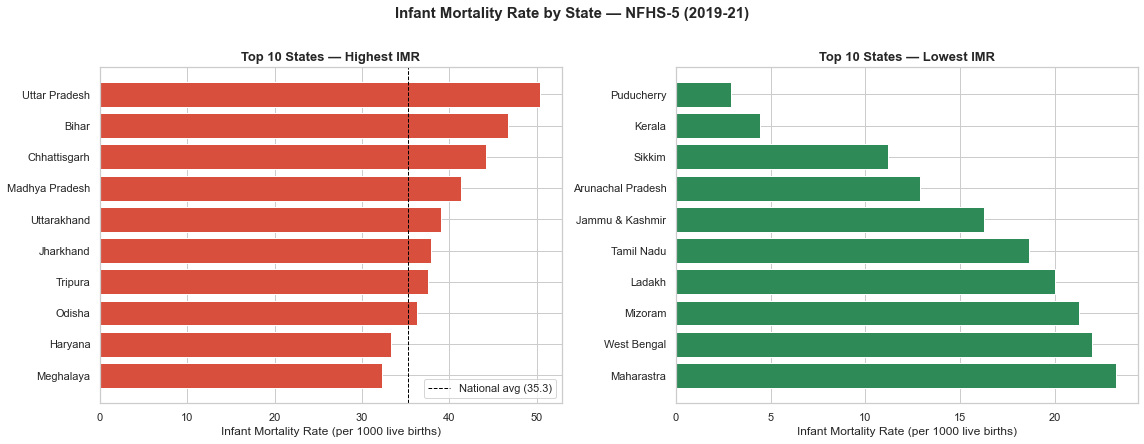

 Chart saved


In [4]:
# Drop nulls for IMR
imr_data = df_total[['state', 'IMR']].dropna().sort_values('IMR', ascending=False)

top10 = imr_data.head(10)
bottom10 = imr_data.tail(10).sort_values('IMR')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 worst
axes[0].barh(top10['state'], top10['IMR'], color='#D94F3D')
axes[0].set_title('Top 10 States — Highest IMR', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Infant Mortality Rate (per 1000 live births)')
axes[0].axvline(x=35.3, color='black', linestyle='--', linewidth=1, label='National avg (35.3)')
axes[0].legend()
axes[0].invert_yaxis()

# Bottom 10 best
axes[1].barh(bottom10['state'], bottom10['IMR'], color='#2E8B57')
axes[1].set_title('Top 10 States — Lowest IMR', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Infant Mortality Rate (per 1000 live births)')
axes[1].invert_yaxis()

plt.suptitle('Infant Mortality Rate by State — NFHS-5 (2019-21)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\Suhani\Desktop\india-health-analysis\assets\01_IMR_top_bottom.png", 
            bbox_inches='tight')
plt.show()
print(" Chart saved")

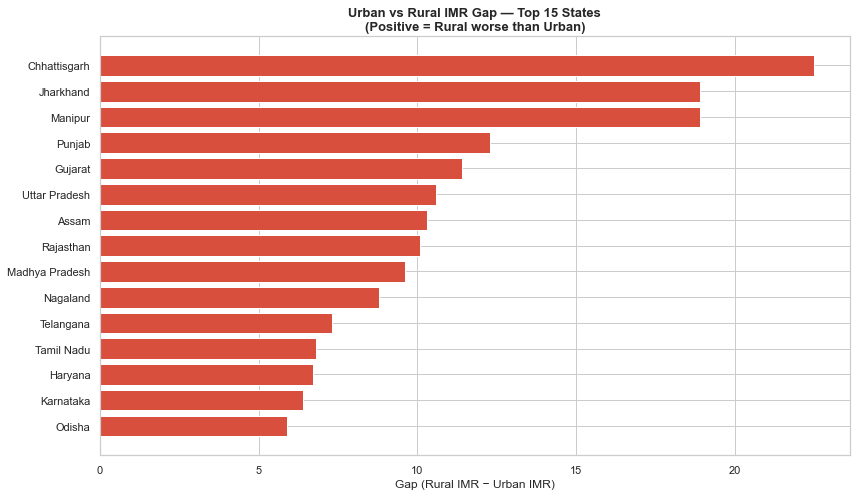

 Chart saved


In [7]:
# Urban vs Rural IMR gap
urban_imr = df_urban[['state', 'IMR']].dropna().rename(columns={'IMR': 'urban_IMR'})
rural_imr = df_rural[['state', 'IMR']].dropna().rename(columns={'IMR': 'rural_IMR'})

gap_df = urban_imr.merge(rural_imr, on='state')
gap_df['gap'] = round(gap_df['rural_IMR'] - gap_df['urban_IMR'], 1)
gap_df = gap_df.sort_values('gap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#D94F3D' if x > 0 else '#2E8B57' for x in gap_df['gap']]
ax.barh(gap_df['state'], gap_df['gap'], color=colors)
ax.set_title('Urban vs Rural IMR Gap — Top 15 States\n(Positive = Rural worse than Urban)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gap (Rural IMR − Urban IMR)')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(r"C:\Users\Suhani\Desktop\india-health-analysis\assets\02_urban_rural_IMR_gap.png",
            bbox_inches='tight')
plt.show()
print(" Chart saved")

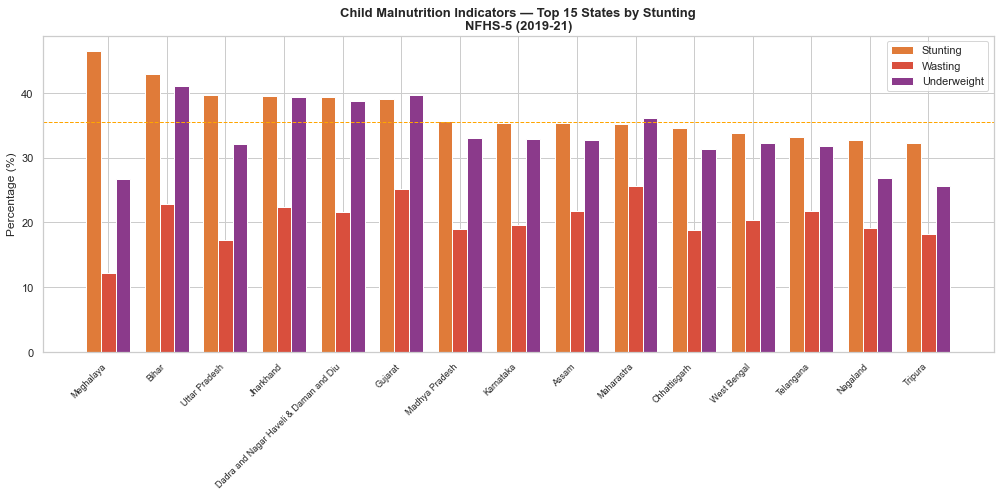

Chart saved


In [9]:
# Malnutrition — stunting, wasting, underweight for top 15 worst states
mal_data = df_total[['state', 'stunting_pct', 'wasting_pct', 'underweight_pct']].dropna()
mal_data = mal_data.sort_values('stunting_pct', ascending=False).head(15)

x = range(len(mal_data))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar([i - width for i in x], mal_data['stunting_pct'], width, label='Stunting', color='#E07B39')
ax.bar([i for i in x], mal_data['wasting_pct'], width, label='Wasting', color='#D94F3D')
ax.bar([i + width for i in x], mal_data['underweight_pct'], width, label='Underweight', color='#8B3A8B')

ax.set_xticks(list(x))
ax.set_xticklabels(mal_data['state'], rotation=45, ha='right', fontsize=9)
ax.set_title('Child Malnutrition Indicators — Top 15 States by Stunting\nNFHS-5 (2019-21)', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.legend()
ax.axhline(y=35.47, color='orange', linestyle='--', linewidth=1, label='National stunting avg')

plt.tight_layout()
plt.savefig(r"C:\Users\Suhani\Desktop\india-health-analysis\assets\03_malnutrition_comparison.png",
            bbox_inches='tight')
plt.show()
print("Chart saved")

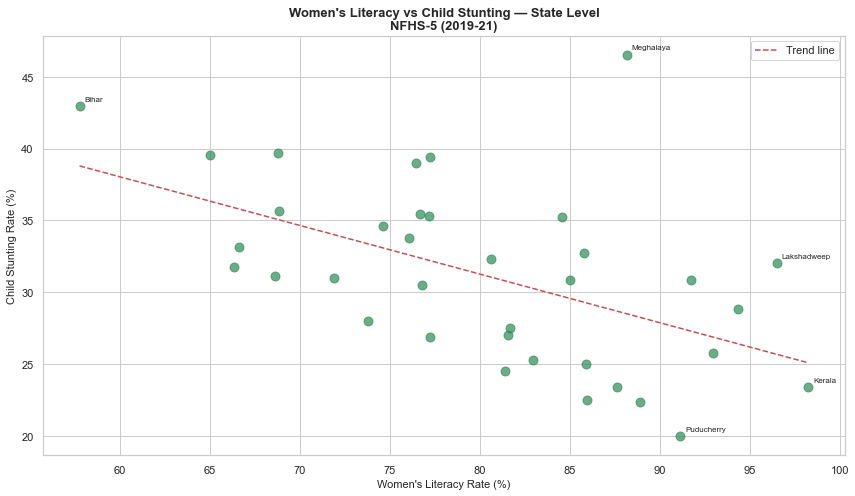

Chart saved


In [10]:
# Scatter — women literacy vs stunting
scatter_data = df_total[['state', 'women_literacy_pct', 'stunting_pct']].dropna()

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(scatter_data['women_literacy_pct'], scatter_data['stunting_pct'], 
           color='#2E8B57', s=80, alpha=0.7)

# Add state labels for outliers
for _, row in scatter_data.iterrows():
    if row['stunting_pct'] > 40 or row['stunting_pct'] < 22 or row['women_literacy_pct'] > 95:
        ax.annotate(row['state'], (row['women_literacy_pct'], row['stunting_pct']),
                   fontsize=8, xytext=(5, 5), textcoords='offset points')

# Trend line
z = np.polyfit(scatter_data['women_literacy_pct'], scatter_data['stunting_pct'], 1)
p = np.poly1d(z)
ax.plot(sorted(scatter_data['women_literacy_pct']), 
        p(sorted(scatter_data['women_literacy_pct'])), 
        'r--', linewidth=1.5, label='Trend line')

ax.set_xlabel("Women's Literacy Rate (%)", fontsize=11)
ax.set_ylabel('Child Stunting Rate (%)', fontsize=11)
ax.set_title("Women's Literacy vs Child Stunting — State Level\nNFHS-5 (2019-21)", 
             fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\Suhani\Desktop\india-health-analysis\assets\04_literacy_vs_stunting.png",
            bbox_inches='tight')
plt.show()
print("Chart saved")

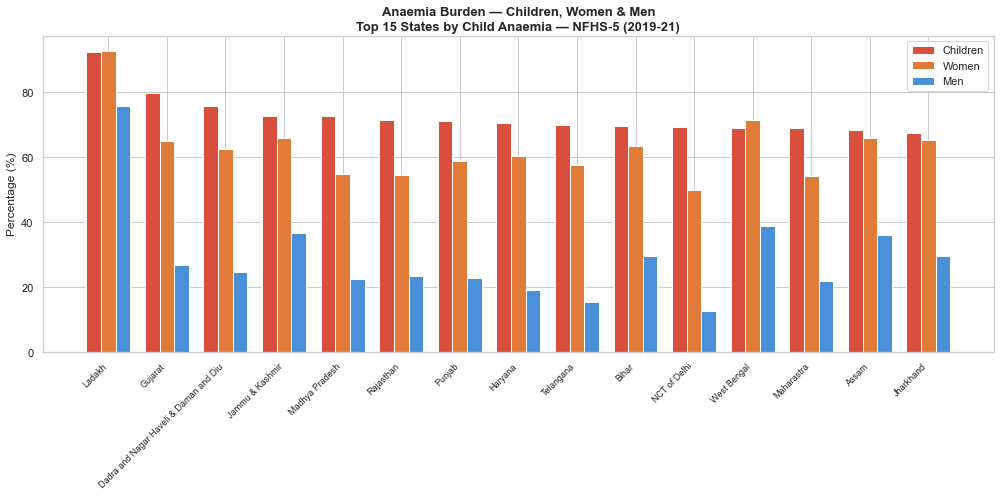

 Chart saved


In [11]:
# Anaemia — child, women, men comparison top 15
anaemia_data = df_total[['state', 'child_anaemia_pct', 'women_anaemia_pct', 'men_anaemia_pct']].dropna()
anaemia_data = anaemia_data.sort_values('child_anaemia_pct', ascending=False).head(15)

x = range(len(anaemia_data))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar([i - width for i in x], anaemia_data['child_anaemia_pct'], width, label='Children', color='#D94F3D')
ax.bar([i for i in x], anaemia_data['women_anaemia_pct'], width, label='Women', color='#E07B39')
ax.bar([i + width for i in x], anaemia_data['men_anaemia_pct'], width, label='Men', color='#4A90D9')

ax.set_xticks(list(x))
ax.set_xticklabels(anaemia_data['state'], rotation=45, ha='right', fontsize=9)
ax.set_title('Anaemia Burden — Children, Women & Men\nTop 15 States by Child Anaemia — NFHS-5 (2019-21)', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\Suhani\Desktop\india-health-analysis\assets\05_anaemia_burden.png",
            bbox_inches='tight')
plt.show()
print(" Chart saved")

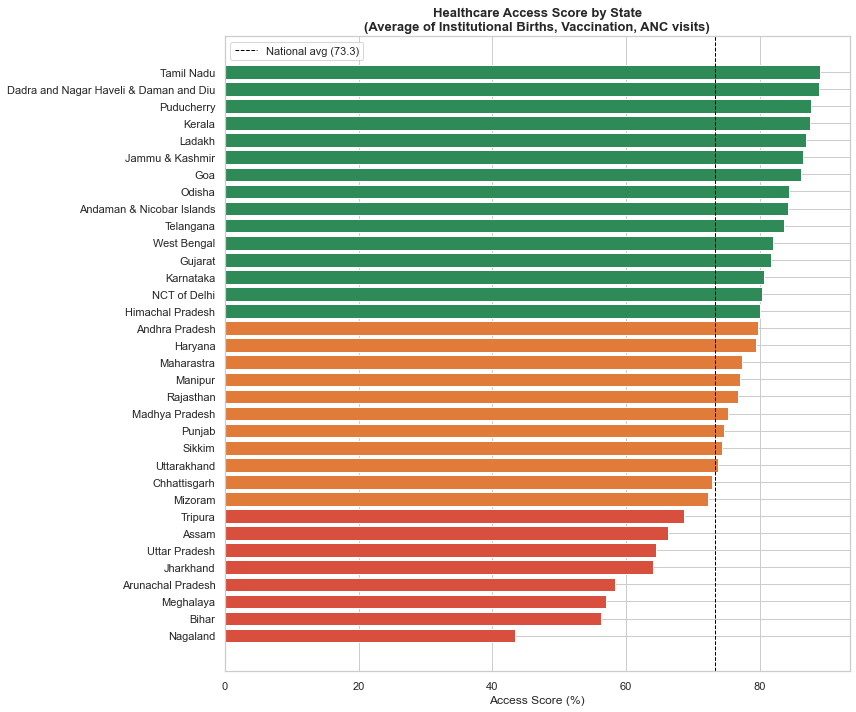

Chart saved


In [14]:
# Healthcare access score bar chart
access_data = df_total[['state', 'Institutional_births_pct', 
                          'full_vaccination_pct', 'ANC_trimester_pct', 
                          'ANC_4visits_pct']].dropna()
access_data['access_score'] = round((access_data['Institutional_births_pct'] + 
                                      access_data['full_vaccination_pct'] + 
                                      access_data['ANC_trimester_pct'] + 
                                      access_data['ANC_4visits_pct']) / 4, 1)
access_data = access_data.sort_values('access_score', ascending=True)

colors = ['#D94F3D' if x < 70 else '#E07B39' if x < 80 else '#2E8B57' 
          for x in access_data['access_score']]

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(access_data['state'], access_data['access_score'], color=colors)
ax.set_title('Healthcare Access Score by State\n(Average of Institutional Births, Vaccination, ANC visits)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Access Score (%)')
ax.axvline(x=73.3, color='black', linestyle='--', linewidth=1, label='National avg (73.3)')
ax.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\Suhani\Desktop\india-health-analysis\assets\06_healthcare_access_score.png",
            bbox_inches='tight')
plt.show()
print("Chart saved")

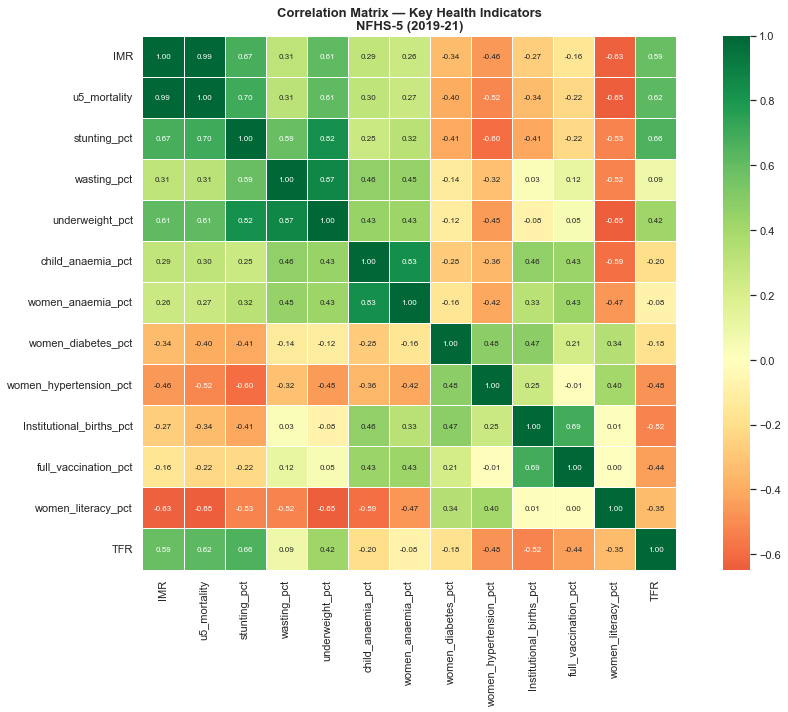

Chart saved


In [16]:
# Correlation heatmap
corr_cols = ['IMR', 'u5_mortality', 'stunting_pct', 'wasting_pct', 
             'underweight_pct', 'child_anaemia_pct', 'women_anaemia_pct',
             'women_diabetes_pct', 'women_hypertension_pct',
             'Institutional_births_pct', 'full_vaccination_pct',
             'women_literacy_pct', 'TFR']

corr_data = df_total[corr_cols].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix — Key Health Indicators\nNFHS-5 (2019-21)', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\Suhani\Desktop\india-health-analysis\assets\07_correlation_heatmap.png",
            bbox_inches='tight')
plt.show()
print("Chart saved")